In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [42]:
data=pd.read_csv('/content/solar_power_prediction_project_dataset_10000(1).csv')

In [43]:
data.head(12)

,Record_ID,Operator_Name,Installation_ID,Time,Solar_Irradiance,Panel_Temperature,Ambient_Temperature,Cloud_Cover,Humidity,Wind_Speed,Rainfall,Dust_Level,Panel_Efficiency,Inverter_Efficiency,Solar_Power_Output
0,100001,Priya,INST-1409,23:30,0.0,19.8,21.3,39.6,75.6,8.2,0.0,17.7,17.19,92.66,0.00
1,100002,Ravi,INST-4257,22:45,0.0,33.4,32.1,37.6,20.5,12.1,0.0,20.9,19.04,93.09,0.18
2,100003,Meena,INST-2674,2:45,0.0,38.8,38.3,27.7,80.5,10.9,0.0,16.1,22.84,94.65,0.02
3,100004,Meena,INST-4150,22:00,0.0,22.6,23.5,23.7,26.0,3.5,0.0,3.0,18.67,96.45,0.00
4,100005,Meena,INST-6820,6:30,7.3,20.3,19.7,63.2,60.1,3.7,11.6,8.1,22.55,96.82,0.00
5,100006,Meena,INST-1916,7:00,98.6,22.1,19.6,72.5,62.5,10.8,5.3,15.0,22.31,96.50,0.05
6,100007,Arun,INST-5040,23:30,0.0,28.6,28.3,79.8,47.1,15.0,3.5,14.8,21.53,98.03,0.00
7,100008,Arun,INST-7916,19:00,0.0,32.2,32.3,50.8,38.9,8.3,23.6,20.4,17.69,98.19,0.10
8,100009,Meena,INST-2827,9:45,603.4,41.2,35.3,14.2,92.9,11.4,0.0,15.2,17.64,96.38,1.08
9,100010,Kumar,INST-3504,11:15,586.3,33.6,30.7,48.5,44.3,0.3,23.2,26.4,21.99,94.15,0.88


In [44]:
data.shape

(10000, 15)

In [45]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Record_ID            10000 non-null  int64  
 1   Operator_Name        10000 non-null  object 
 2   Installation_ID      10000 non-null  object 
 3   Time                 10000 non-null  object 
 4   Solar_Irradiance     10000 non-null  float64
 5   Panel_Temperature    10000 non-null  float64
 6   Ambient_Temperature  10000 non-null  float64
 7   Cloud_Cover          10000 non-null  float64
 8   Humidity             10000 non-null  float64
 9   Wind_Speed           10000 non-null  float64
 10  Rainfall             10000 non-null  float64
 11  Dust_Level           10000 non-null  float64
 12  Panel_Efficiency     10000 non-null  float64
 13  Inverter_Efficiency  10000 non-null  float64
 14  Solar_Power_Output   10000 non-null  float64
dtypes: float64(11), int64(1), object(3)
m

In [46]:
data.describe()

,Record_ID,Solar_Irradiance,Panel_Temperature,Ambient_Temperature,Cloud_Cover,Humidity,Wind_Speed,Rainfall,Dust_Level,Panel_Efficiency,Inverter_Efficiency,Solar_Power_Output
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,105000.50000,199.220270,31.748460,30.075530,51.647610,57.140840,7.483650,8.012380,15.000060,20.018924,95.521923,0.377437
std,2886.89568,264.283713,7.289964,6.899963,25.885839,21.632087,4.304756,8.371119,8.686906,1.734296,2.012363,0.459758
min,100001.00000,0.000000,16.300000,18.000000,0.000000,20.000000,0.000000,0.000000,0.000000,17.000000,92.000000,0.000000
25%,102500.75000,0.000000,25.875000,24.100000,30.675000,38.400000,3.800000,0.000000,7.400000,18.510000,93.780000,0.000000
50%,105000.50000,2.650000,31.800000,30.200000,52.050000,56.900000,7.500000,5.300000,15.100000,20.030000,95.530000,0.160000
75%,107500.25000,368.825000,37.600000,36.000000,73.325000,76.100000,11.200000,15.300000,22.500000,21.520000,97.250000,0.650000
max,110000.00000,1000.000000,51.000000,42.000000,100.000000,95.000000,15.000000,25.000000,30.000000,23.000000,99.000000,2.270000


In [47]:
data.isnull().sum()

,0
Record_ID,0
Operator_Name,0
Installation_ID,0
Time,0
Solar_Irradiance,0
Panel_Temperature,0
Ambient_Temperature,0
Cloud_Cover,0
Humidity,0
Wind_Speed,0


In [48]:
(data.isnull().sum()/len(data))*100

,0
Record_ID,0.0
Operator_Name,0.0
Installation_ID,0.0
Time,0.0
Solar_Irradiance,0.0
Panel_Temperature,0.0
Ambient_Temperature,0.0
Cloud_Cover,0.0
Humidity,0.0
Wind_Speed,0.0


In [49]:
data.duplicated().sum()

np.int64(0)

In [50]:
data = data.drop(["Record_ID","Operator_Name","Installation_ID"], axis=1)

In [51]:
data["Hour"] = pd.to_datetime(data["Time"]).dt.hour

In [52]:
data = data.drop("Time", axis=1)

In [53]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Solar_Irradiance     10000 non-null  float64
 1   Panel_Temperature    10000 non-null  float64
 2   Ambient_Temperature  10000 non-null  float64
 3   Cloud_Cover          10000 non-null  float64
 4   Humidity             10000 non-null  float64
 5   Wind_Speed           10000 non-null  float64
 6   Rainfall             10000 non-null  float64
 7   Dust_Level           10000 non-null  float64
 8   Panel_Efficiency     10000 non-null  float64
 9   Inverter_Efficiency  10000 non-null  float64
 10  Solar_Power_Output   10000 non-null  float64
 11  Hour                 10000 non-null  int32  
dtypes: float64(11), int32(1)
memory usage: 898.6 KB


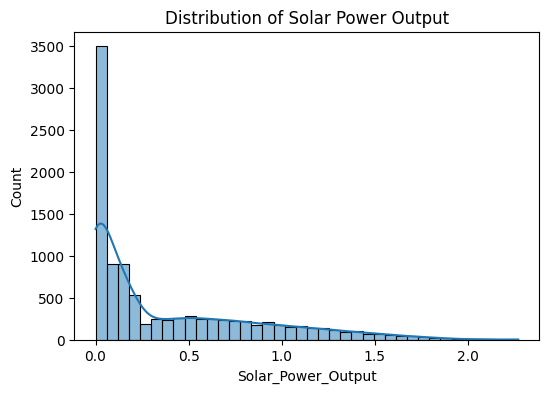

In [54]:
plt.figure(figsize=(6,4))
sns.histplot(data["Solar_Power_Output"], kde=True)
plt.title("Distribution of Solar Power Output")
plt.show()

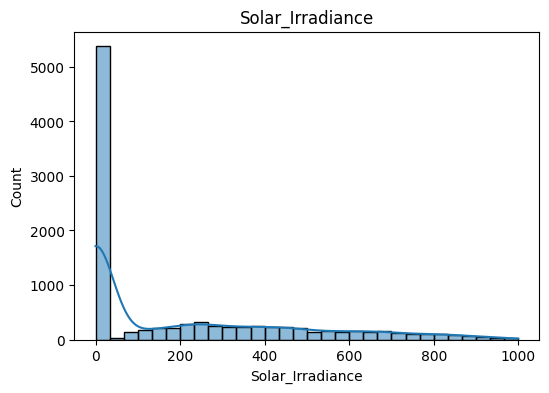

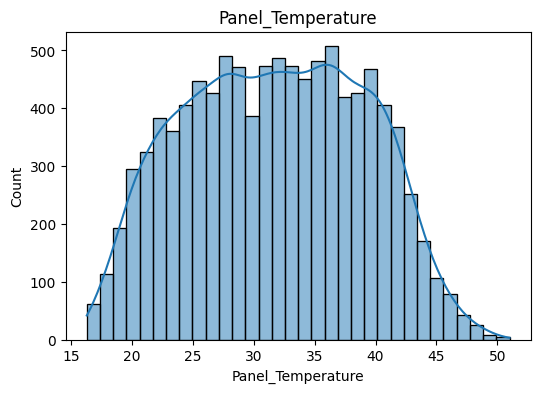

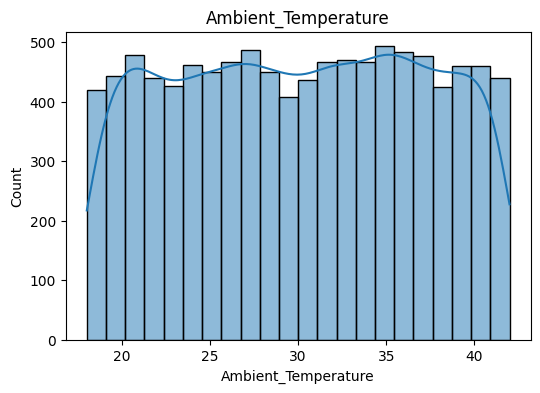

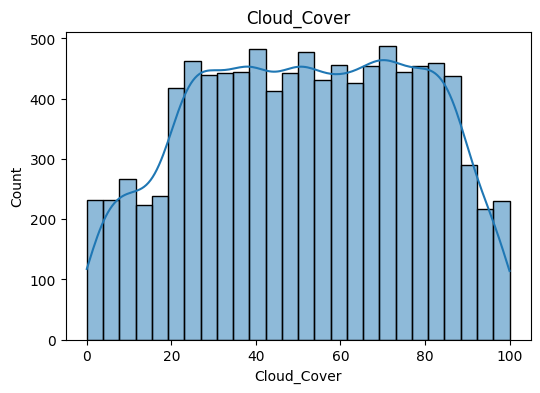

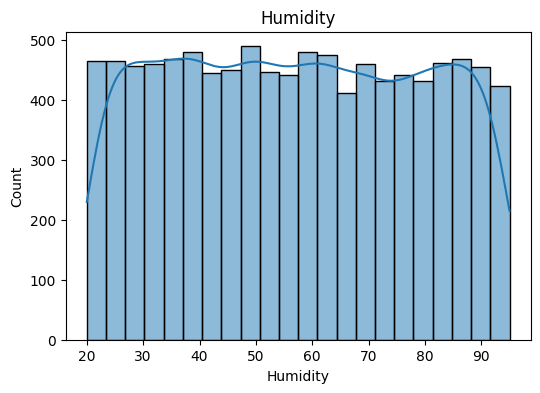

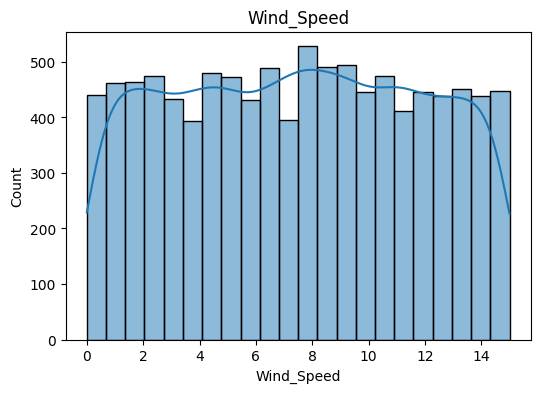

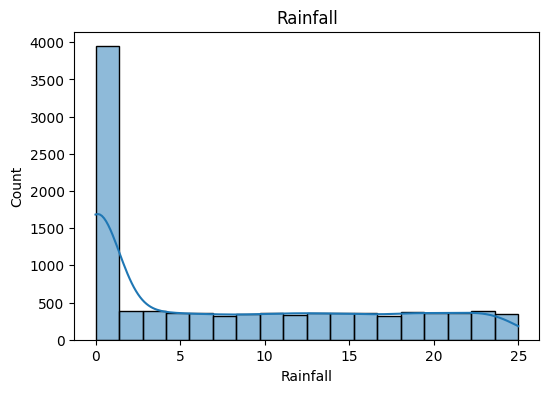

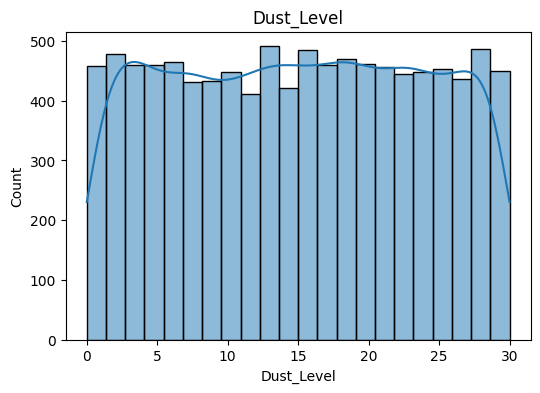

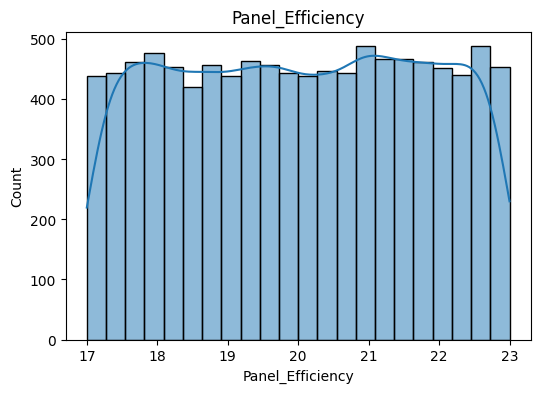

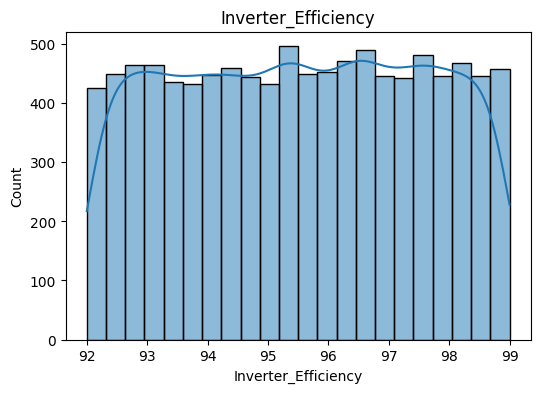

In [55]:
columns = [
    "Solar_Irradiance",
    "Panel_Temperature",
    "Ambient_Temperature",
    "Cloud_Cover",
    "Humidity",
    "Wind_Speed",
    "Rainfall",
    "Dust_Level",
    "Panel_Efficiency",
    "Inverter_Efficiency"
]

for col in columns:
    plt.figure(figsize=(6,4))
    sns.histplot(data[col], kde=True)
    plt.title(col)
    plt.show()

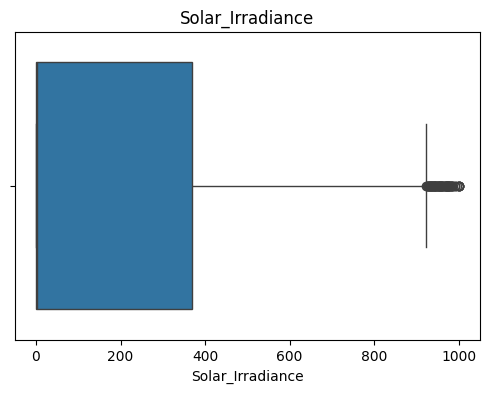

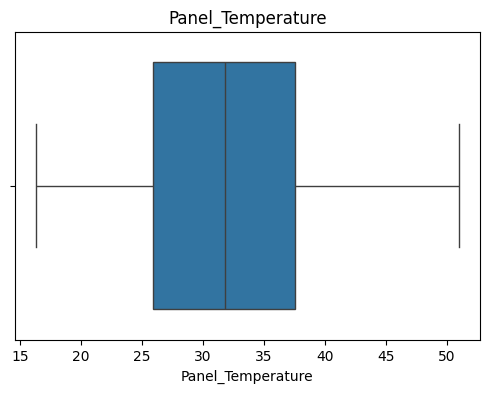

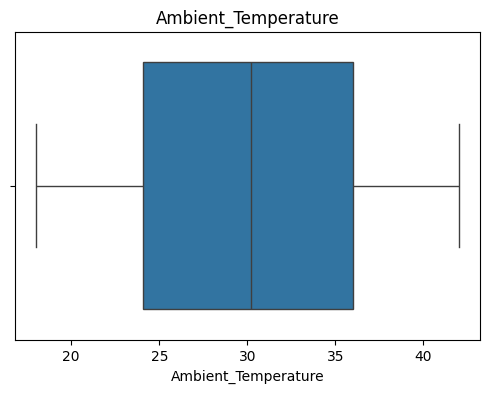

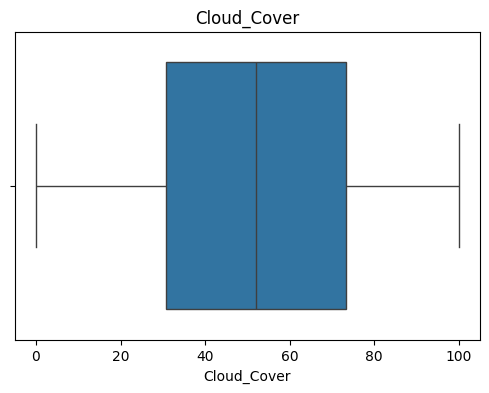

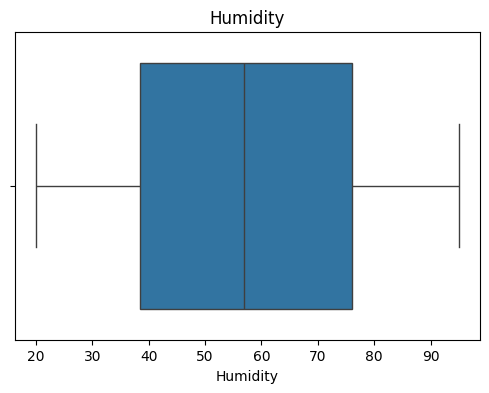

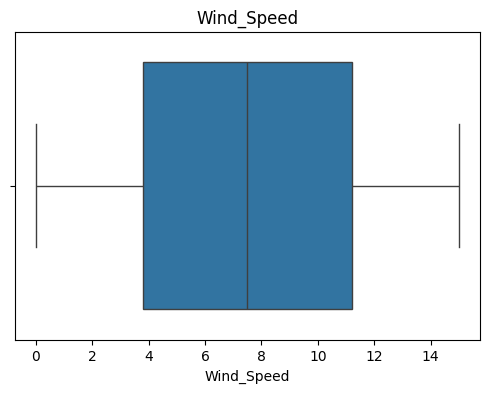

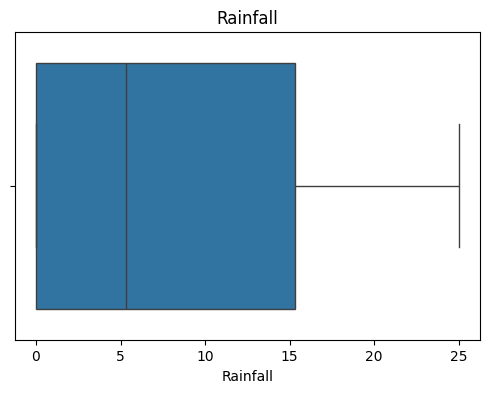

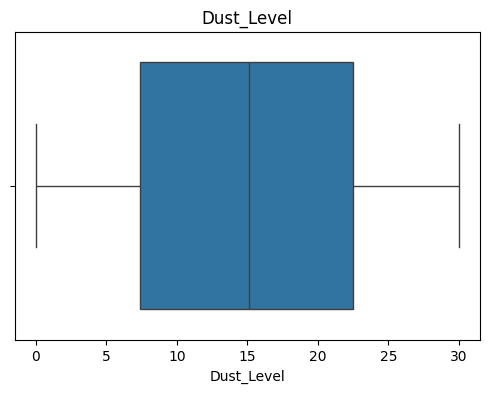

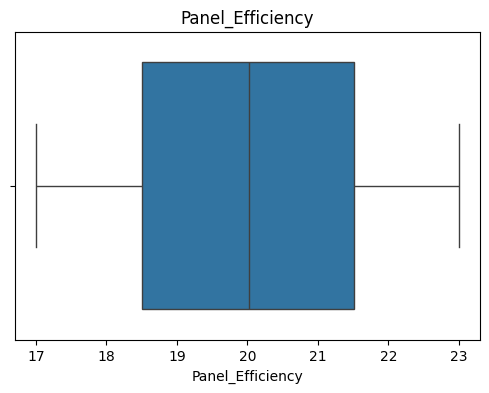

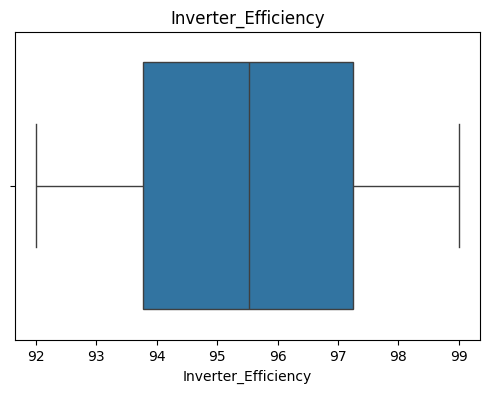

In [56]:
for col in columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=data[col])
    plt.title(col)
    plt.show()

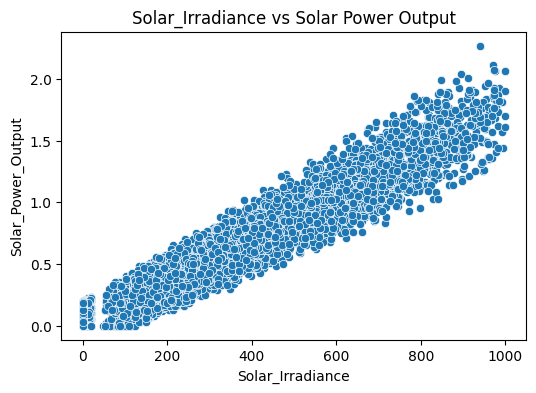

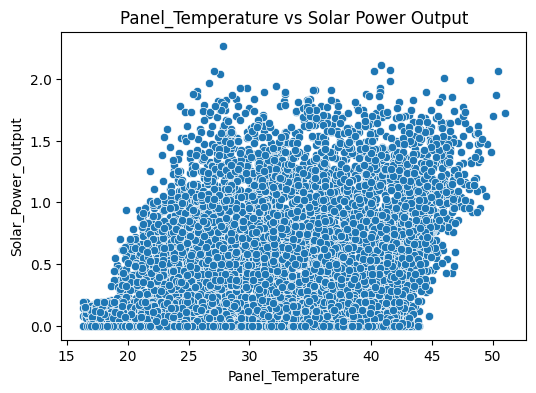

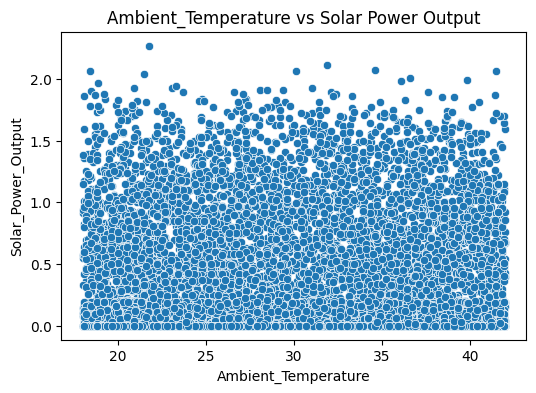

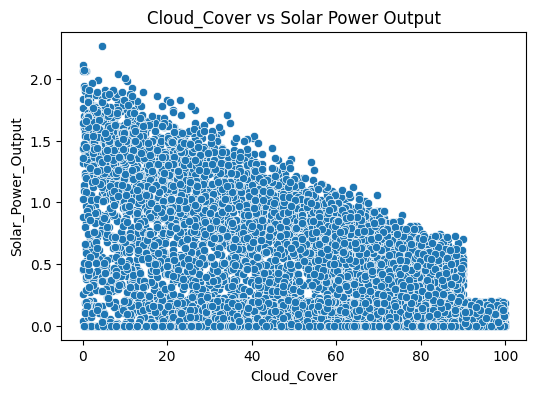

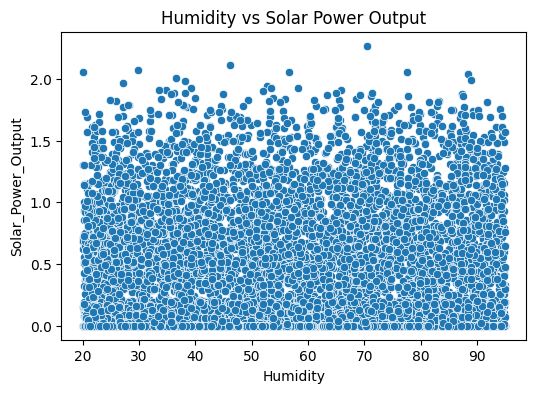

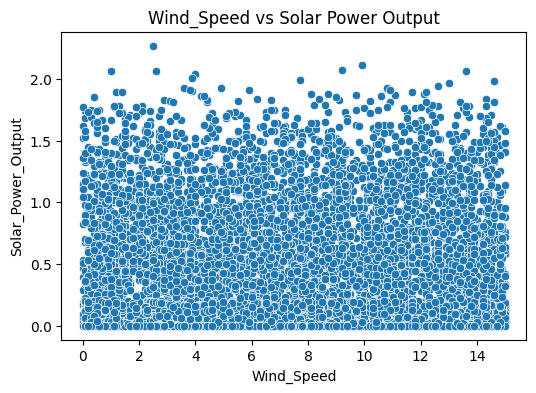

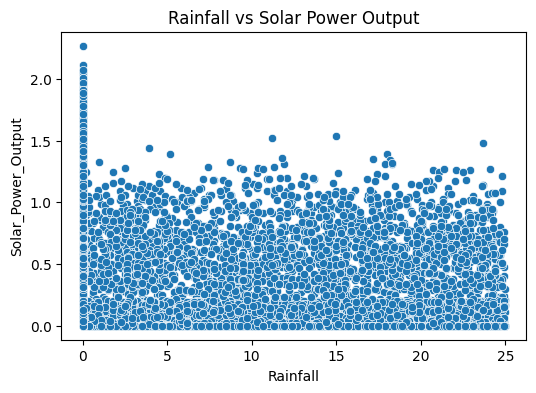

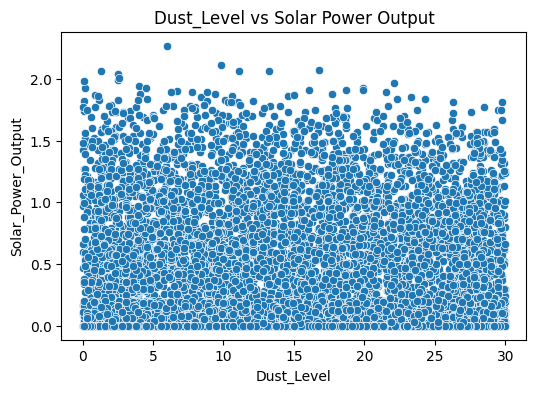

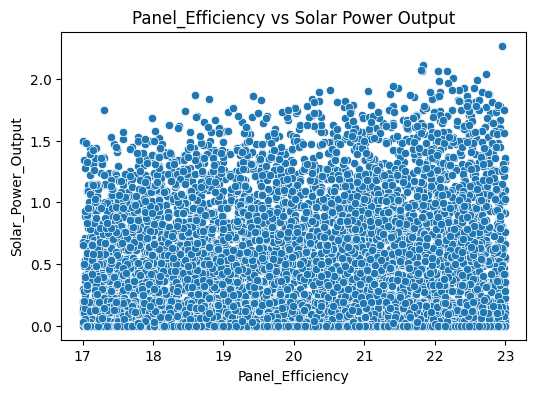

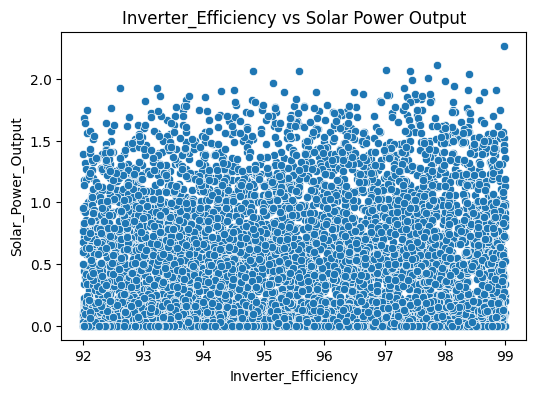

In [57]:
features = [
    "Solar_Irradiance",
    "Panel_Temperature",
    "Ambient_Temperature",
    "Cloud_Cover",
    "Humidity",
    "Wind_Speed",
    "Rainfall",
    "Dust_Level",
    "Panel_Efficiency",
    "Inverter_Efficiency"
]

for col in features:
    plt.figure(figsize=(6,4))
    sns.scatterplot(
        x=data[col],
        y=data["Solar_Power_Output"]
    )
    plt.title(f"{col} vs Solar Power Output")
    plt.show()

In [58]:
corr=data.corr()
corr

,Solar_Irradiance,Panel_Temperature,Ambient_Temperature,Cloud_Cover,Humidity,Wind_Speed,Rainfall,Dust_Level,Panel_Efficiency,Inverter_Efficiency,Solar_Power_Output,Hour
Solar_Irradiance,1.000000,0.287034,-0.015155,-0.447513,0.012097,-0.010247,-0.264207,0.002281,0.006756,-0.006751,0.970479,0.059492
Panel_Temperature,0.287034,1.000000,0.940378,-0.118754,-0.003844,-0.004736,-0.078458,-0.012134,0.020311,-0.001816,0.279438,0.004171
Ambient_Temperature,-0.015155,0.940378,1.000000,0.016096,-0.005295,-0.003296,0.000442,-0.012421,0.019125,-0.000539,-0.013294,-0.011814
Cloud_Cover,-0.447513,-0.118754,0.016096,1.000000,-0.007794,-0.004269,0.592816,0.008500,-0.010840,0.008121,-0.443830,-0.011393
Humidity,0.012097,-0.003844,-0.005295,-0.007794,1.000000,-0.016524,-0.009006,-0.020016,-0.018719,0.003845,0.012012,-0.000150
Wind_Speed,-0.010247,-0.004736,-0.003296,-0.004269,-0.016524,1.000000,0.016040,0.007675,-0.003133,-0.003713,-0.010703,0.005018
Rainfall,-0.264207,-0.078458,0.000442,0.592816,-0.009006,0.016040,1.000000,0.005361,-0.003378,0.008520,-0.262309,0.002877
Dust_Level,0.002281,-0.012134,-0.012421,0.008500,-0.020016,0.007675,0.005361,1.000000,0.020565,-0.001925,-0.030870,0.012161
Panel_Efficiency,0.006756,0.020311,0.019125,-0.010840,-0.018719,-0.003133,-0.003378,0.020565,1.000000,0.012514,0.074656,0.006395
Inverter_Efficiency,-0.006751,-0.001816,-0.000539,0.008121,0.003845,-0.003713,0.008520,-0.001925,0.012514,1.000000,0.010618,-0.001975


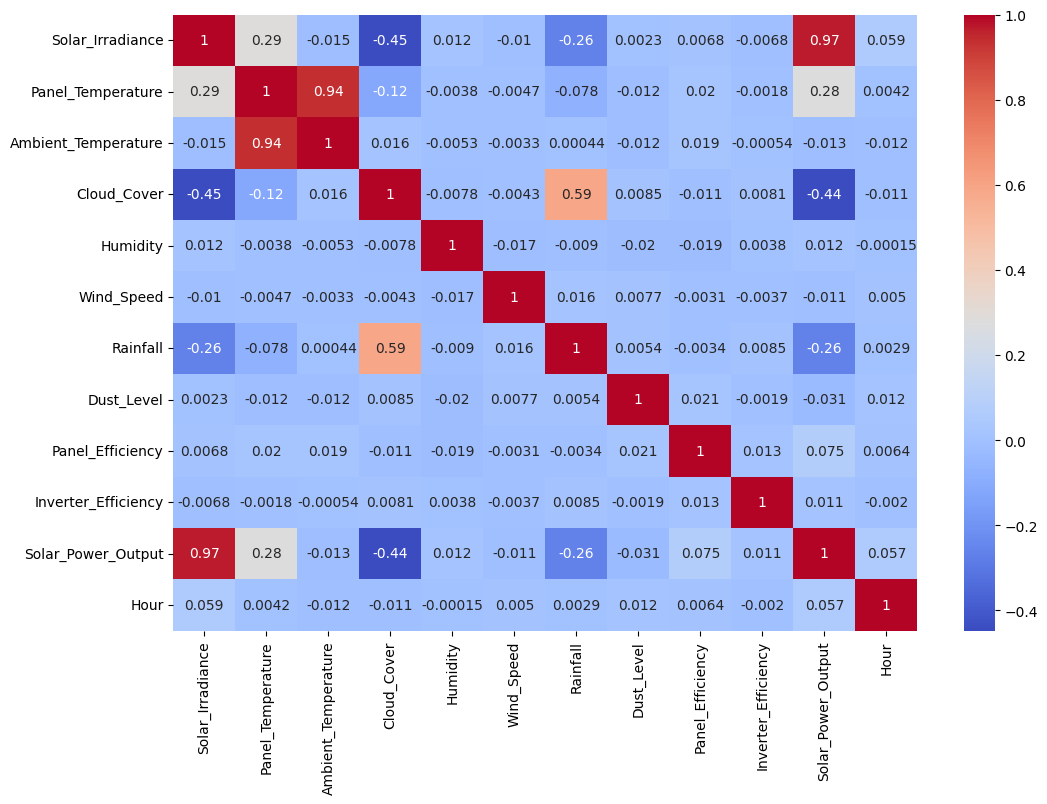

In [59]:
plt.figure(figsize=(12,8))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm")
plt.show()

In [60]:
Q1 = data["Solar_Irradiance"].quantile(0.25)
Q3 = data["Solar_Irradiance"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = data[(data["Solar_Irradiance"] < lower) | (data["Solar_Irradiance"] > upper)]

print(len(outliers))

82


In [61]:
X = data.drop("Solar_Power_Output", axis=1)
y = data["Solar_Power_Output"]

In [62]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [63]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
reg = RandomForestRegressor(random_state=42)
n_estimators = [25, 50, 75, 100, 125, 150, 175, 200]
criterion = ['squared_error']
max_depth = [3, 5, 10]

parameters = {
    'n_estimators': n_estimators,
    'criterion': criterion,
    'max_depth': max_depth
}
grid_search = GridSearchCV(
    estimator=reg,
    param_grid=parameters,
    cv=5,
    scoring='r2',
    n_jobs=-1)

In [64]:
grid_search.fit(X_train, y_train)
print("Best Parameters:", grid_search.best_params_)
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)

Best Parameters: {'criterion': 'squared_error', 'max_depth': 10, 'n_estimators': 200}


In [65]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

print("R2 Score :", r2_score(y_test, y_pred))
print("MAE      :", mean_absolute_error(y_test, y_pred))
print("MSE      :", mean_squared_error(y_test, y_pred))
print("RMSE     :", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score : 0.9558810122556503
MAE      : 0.07872538729988716
MSE      : 0.009343896666850445
RMSE     : 0.09666383329275974


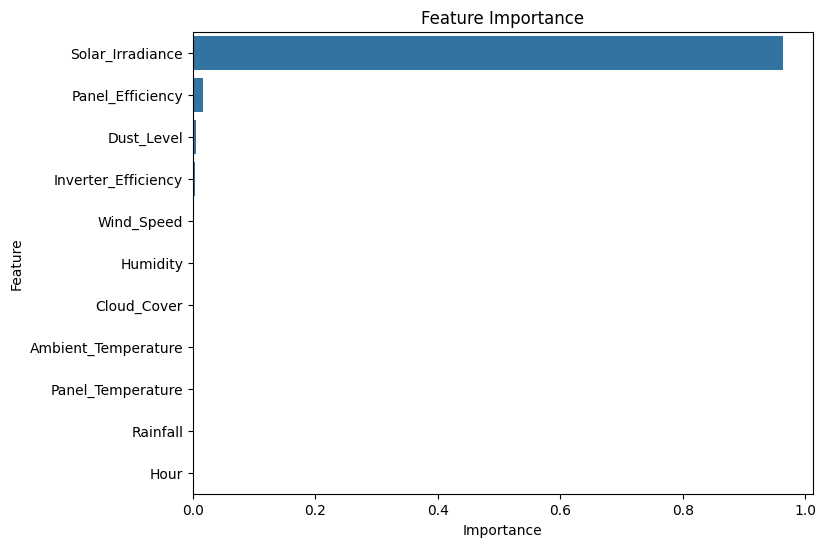

In [66]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_rf.feature_importances_
})
importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(8,6))
sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")
plt.show()